# Exploring a neutrino-factory HDF5 output file


In [2]:
%matplotlib inline

import os
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt

from neutrino_factory import kinematics
from neutrino_factory.common_output import EVENT_NUMERIC_FIELDS, EVENT_STRING_FIELDS
from neutrino_factory.plots import (
    dataset_title,
    figure_xsec,
    interaction_counts,
    log_bin_edges,
    plot_energy,
    plot_interactions,
    plot_xsec_by_interaction,
    read_plot_data,
)

plt.rcParams["figure.dpi"] = 110

In [4]:
def repository_root(start=None) -> Path:
    """Walk up from `start` (default: the cwd) to the directory holding pyproject.toml."""
    here = Path(start or Path.cwd()).resolve()
    for candidate in (here, *here.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    return here


ROOT = repository_root()
# This path should correspond to the output path set in the config file (here: `configs/high_stats_test.yml`).
MERGED_DIR = Path("/ptmp/mpp/atrettin/neutrino_factory/output/four_generators_gridtest") / "merged"

available = sorted(MERGED_DIR.glob("*.h5"))
print(f"merged outputs under {MERGED_DIR}:")
for path in available:
    print(f"  {path.name}")

# Point this at any file above (or an absolute path of your own).
DATA_FILE = available[0] if available else None
if DATA_FILE is None:
    raise SystemExit(
        f"No merged HDF5 files under {MERGED_DIR}. Run a job first — see the "
        "intro cell — or set DATA_FILE by hand."
    )
print(f"\nusing: {DATA_FILE}")

merged outputs under /ptmp/mpp/atrettin/neutrino_factory/output/four_generators_gridtest/merged:
  four_generators_gridtest_genie_R-3_06_00_AR23_20i_00_000_numu_Ar40_inclusive.h5
  four_generators_gridtest_genie_R-3_06_00_AR23_20i_00_000_numu_C12_inclusive.h5
  four_generators_gridtest_genie_R-3_06_00_AR23_20i_00_000_numubar_Ar40_inclusive.h5
  four_generators_gridtest_genie_R-3_06_00_AR23_20i_00_000_numubar_C12_inclusive.h5
  four_generators_gridtest_genie_R-3_06_00_G18_10a_02_11a_numu_Ar40_inclusive.h5
  four_generators_gridtest_genie_R-3_06_00_G18_10a_02_11a_numu_C12_inclusive.h5
  four_generators_gridtest_genie_R-3_06_00_G18_10a_02_11a_numubar_Ar40_inclusive.h5
  four_generators_gridtest_genie_R-3_06_00_G18_10a_02_11a_numubar_C12_inclusive.h5
  four_generators_gridtest_gibuu_release2025_default_numu_Ar40_inclusive.h5
  four_generators_gridtest_gibuu_release2025_default_numu_C12_inclusive.h5
  four_generators_gridtest_gibuu_release2025_default_numubar_Ar40_inclusive.h5
  four_genera

## 1. What is actually inside the file

Three top-level groups:

| group | what it holds |
|---|---|
| `metadata` | attributes only: generator identity (`generator`, `code_version`, `config_version`), the flux that was simulated, `expected_events`, the merge provenance |
| `run` | attributes only: `event_count`, the number of events actually written |
| `events` | one **1-D dataset per column**, all the same length — this is the event table |

Note the storage choice: `events` is *column-major* (one dataset per variable),
not an array of records. That is why loading only the columns you need is cheap,
and why every plotting helper below takes plain numpy arrays.

The cell below walks the file and prints the structure without assuming
anything about it, so it also works on files written by a future version that
added a column.

In [5]:
def describe(path) -> None:
    """Print every group, attribute and dataset of a common-output file."""
    with h5py.File(path, "r") as handle:
        for group_name in handle:
            group = handle[group_name]
            print(f"/{group_name}")
            for key, value in group.attrs.items():
                text = value.decode() if isinstance(value, bytes) else value
                text = str(text)
                if len(text) > 90:
                    text = text[:87] + "..."
                print(f"    @{key} = {text}")
            for name in group:
                dataset = group[name]
                print(f"    {name:<26} shape={dataset.shape} dtype={dataset.dtype}")


describe(DATA_FILE)

/events
    bjorken_x                  shape=(100000,) dtype=float64
    energy_gev                 shape=(100000,) dtype=float64
    event_id                   shape=(100000,) dtype=int64
    generator                  shape=(100000,) dtype=object
    inelasticity_y             shape=(100000,) dtype=float64
    interaction                shape=(100000,) dtype=object
    is_cc                      shape=(100000,) dtype=bool
    lepton_costheta            shape=(100000,) dtype=float64
    lepton_energy_gev          shape=(100000,) dtype=float64
    lepton_momentum_gev        shape=(100000,) dtype=float64
    lepton_p_parallel_gev      shape=(100000,) dtype=float64
    lepton_p_transverse_gev    shape=(100000,) dtype=float64
    probe                      shape=(100000,) dtype=object
    q2_gev2                    shape=(100000,) dtype=float64
    resonant_primary           shape=(100000,) dtype=int8
    seed                       shape=(100000,) dtype=int64
    target                   

The column names are not hard-coded in this notebook — the package declares
them, and everything downstream (the writer, the reader, the merger) is driven
off that one table. Worth printing once so you know what you can ask for:

In [6]:
print("numeric columns:")
for name in EVENT_NUMERIC_FIELDS:
    print(f"  {name}")
print("\nstring columns:")
for name in EVENT_STRING_FIELDS:
    print(f"  {name}")
print("\nof which derived kinematics:", ", ".join(kinematics.KINEMATIC_FIELDS))

numeric columns:
  event_id
  seed
  energy_gev
  weight
  xsec_weight
  is_cc
  resonant_primary
  q2_gev2
  bjorken_x
  w_gev
  w_true_gev
  inelasticity_y
  lepton_energy_gev
  lepton_momentum_gev
  lepton_p_parallel_gev
  lepton_p_transverse_gev
  lepton_costheta

string columns:
  interaction
  probe
  target
  generator

of which derived kinematics: q2_gev2, bjorken_x, w_gev, w_true_gev, inelasticity_y, lepton_energy_gev, lepton_momentum_gev, lepton_p_parallel_gev, lepton_p_transverse_gev, lepton_costheta


In [7]:
def read_columns(path) -> tuple[dict, dict[str, np.ndarray]]:
    """Read the metadata attributes and every `events` column as a numpy array."""
    with h5py.File(path, "r") as handle:
        metadata = {
            key: (value.decode() if isinstance(value, bytes) else value)
            for key, value in handle["metadata"].attrs.items()
        }
        columns: dict[str, np.ndarray] = {}
        for name, dataset in handle["events"].items():
            values = dataset[()]
            if values.dtype.kind in ("S", "O", "U"):
                columns[name] = np.array(
                    [v.decode() if isinstance(v, bytes) else str(v) for v in values],
                    dtype=object,
                )
            else:
                columns[name] = np.asarray(values)
    return metadata, columns


data = read_plot_data(DATA_FILE)       # what the plots in neutrino_factory.plots want
metadata, cols = read_columns(DATA_FILE)  # every column, including the kinematics

print(dataset_title(data))
print(f"{len(data.energies):,} events written, {metadata['expected_events']:,} requested")
print(f"flux: {metadata['flux']}")

numu on Ar40 — genie R-3_06_00 / AR23_20i_00_000
100,000 events written, 100,000 requested
flux: {"emax_gev": 50.0, "emin_gev": 0.1, "gamma": -2.0, "particle": "numu", "type": "power_law"}


## 3. Placeholders: the columns that are not always defined

The framework refuses to invent physical values. Where a kinematic variable is
undefined for an event, the column carries a deliberately unphysical
placeholder rather than a plausible number:

* **`-1`** for the non-negative quantities (`q2_gev2`, `bjorken_x`,
  `inelasticity_y`, the lepton energies/momenta);
* **`-999`** for `lepton_p_parallel_gev` and `lepton_costheta`, whose physical
  range includes `-1`.

So `bjorken_x == -1` is not "x is minus one", it is "there is no struck nucleon
to define x against" — coherent scattering, for instance. **Always mask
placeholders out before histogramming**, or they pile up in a spike at the
placeholder value and quietly bias every mean you compute.

The per-field placeholder is `kinematics.FIELD_DEFAULTS`, which is also what
`common_output` builds its column table from — so the masking below stays
correct if a column is ever added.

In [40]:
def defined(cols, field: str) -> np.ndarray:
    """Boolean mask of events for which `field` holds a real value."""
    values = cols[field]
    mask = np.isfinite(values)
    placeholder = kinematics.FIELD_DEFAULTS.get(field)
    if placeholder is not None:
        mask &= values != placeholder
    return mask


total = len(cols["energy_gev"])
print(f"{'column':<26} {'defined':>10} {'placeholder':>12}")
for field in kinematics.KINEMATIC_FIELDS:
    n_defined = int(defined(cols, field).sum())
    print(f"{field:<26} {n_defined:>10,} {total - n_defined:>12,}")

column                        defined  placeholder
q2_gev2                       100,000            0
bjorken_x                      99,752          248
w_gev                          99,737          263
w_true_gev                     99,739          261
inelasticity_y                100,000            0
lepton_energy_gev             100,000            0
lepton_momentum_gev           100,000            0
lepton_p_parallel_gev         100,000            0
lepton_p_transverse_gev       100,000            0
lepton_costheta               100,000            0


If the whole table above reads *0 defined*, you are looking at a `stub_mode`
file: the synthetic generator draws energies from the flux but produces no
outgoing lepton, so every derived kinematic column is a placeholder. Sections
4–6 still work; sections 7 and 8 need a real generator run.

## 4. What kind of events are in here?

`interaction` is the harmonized channel label — `qel`, `res`, `dis`, `coh`,
`mec`, `other` — mapped from each generator's own scheme by its normalizer.
`interaction_counts` puts the known labels in canonical order and appends
anything unexpected rather than dropping it (a `stub_mode` file shows a single
`inclusive` label this way).

The dashed line is the requested event count. A gap between it and the bars is
worth understanding before you trust anything else: generators can write fewer
events than asked.

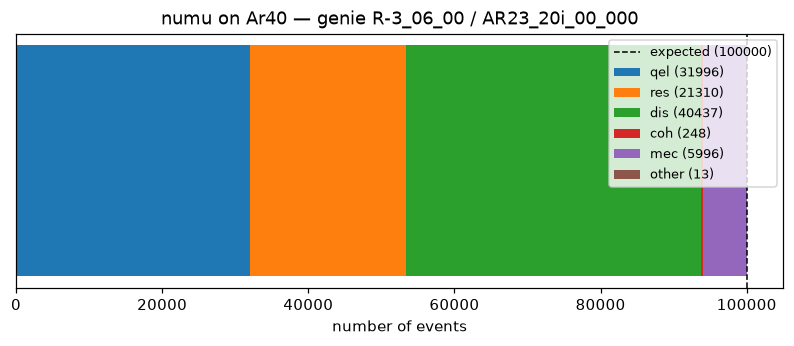

qel             31,996  ( 32.0 %)
res             21,310  ( 21.3 %)
dis             40,437  ( 40.4 %)
coh                248  (  0.2 %)
mec              5,996  (  6.0 %)
other               13  (  0.0 %)


In [9]:
counts = interaction_counts(data.interactions)
fig, ax = plt.subplots(figsize=(9, 3))
plot_interactions(counts, int(data.metadata["expected_events"]), ax)
ax.set_title(dataset_title(data))
plt.show()

for label, count in counts.items():
    print(f"{label:<12} {count:>9,}  ({100 * count / max(len(data.interactions), 1):5.1f} %)")

## 5. The energy spectrum — raw and weighted

Two different questions:

* **Raw counts** answer *where did the generator spend its events?* This is the
  sampling distribution, and it is what determines your statistical
  uncertainties.
* **`weight`-weighted counts** apply each generator's own native weight column,
  passed through verbatim. For a rejection-sampling generator every weight is 1
  and the two panels are the same shape.

Neither of these is a cross section — that is section 6. Both histograms use
log-spaced energy bins and divide each bin by its width, so the y-axis is a
count *per GeV* and bins of unequal width stay comparable.

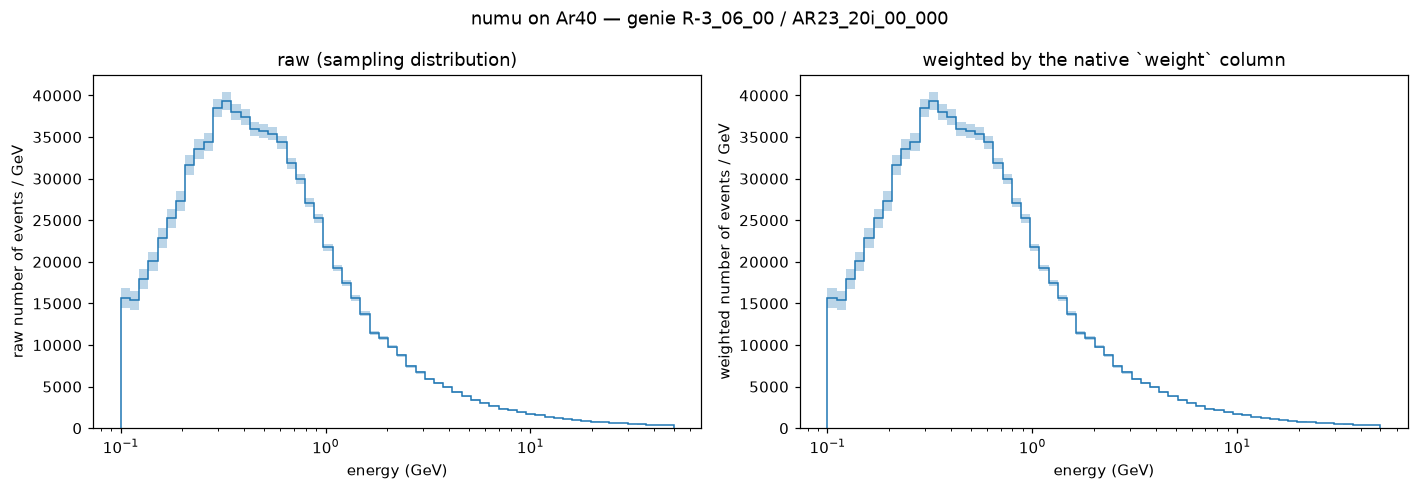

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True)
plot_energy(data.energies, axes[0], bins=60)
axes[0].set_title("raw (sampling distribution)")
plot_energy(data.energies, axes[1], weights=data.weights, bins=60)
axes[1].set_title("weighted by the native `weight` column")
fig.suptitle(dataset_title(data))
fig.tight_layout()
plt.show()

## 6. The cross section vs. energy

This is the plot the whole framework exists to produce. Its contract, stated
once on `ConfigTranslator.compute_xsec_weight` and honoured by every generator:

> Histogram events by energy, weight by `xsec_weight`, divide by the bin width →
> the average differential cross section in that bin, in 1e-38 cm² **per target
> nucleon**.

Per *nucleon*, always — cross sections on different nuclei are otherwise not
comparable quantities. By convention the plots show **σ(E)/E**, so the module
divides each bin by its geometric centre as well; that flattens the roughly
linear rise of the CC total cross section and makes deviations visible.

`plot_xsec_by_interaction` draws one line per channel plus a dashed total.
`figure_xsec` wraps it into one panel per weak current actually present in the
file — so an inclusive run gets a CC and an NC panel sharing a y-axis, and a
CC-only run stays a single panel.

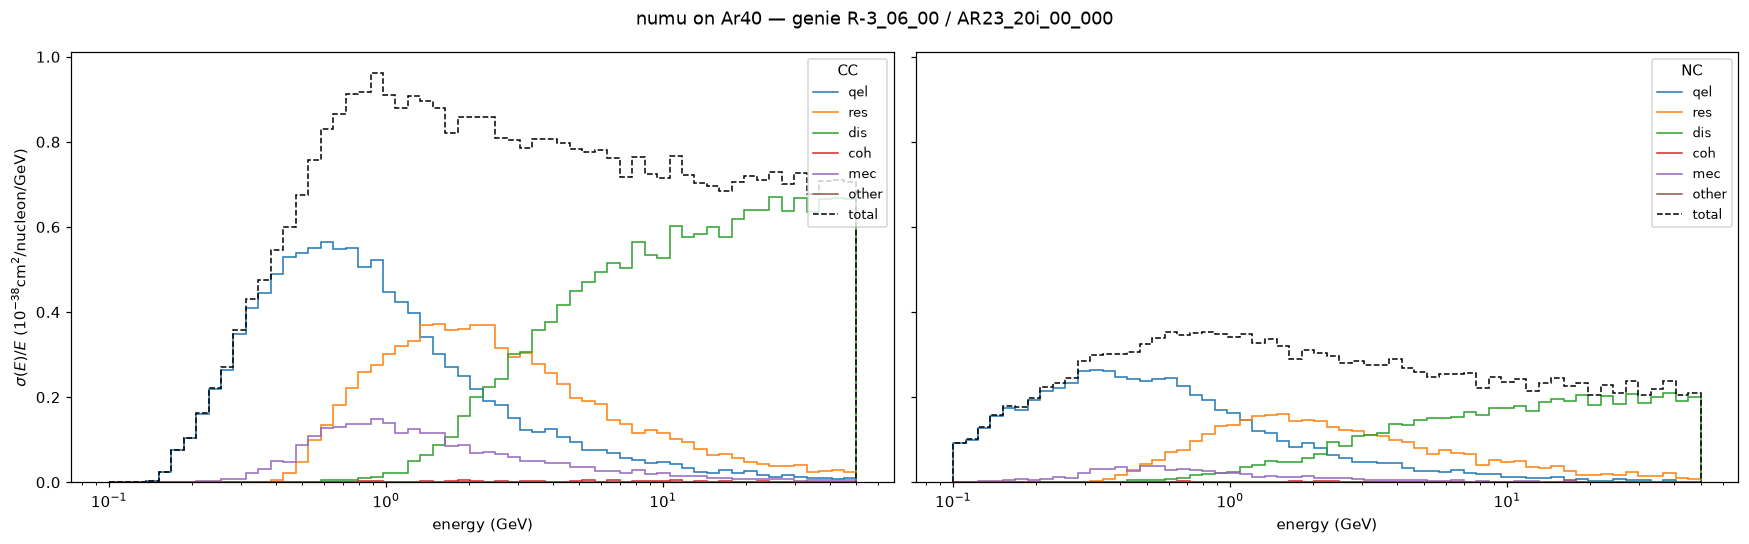

In [11]:
fig = figure_xsec(data, plt, bins=60)
fig.tight_layout()
plt.show()

## 7. Every kinematic variable, weighted by the cross section

**Weighting by `xsec_weight` here is a correctness requirement, not a
refinement.** GiBUU does not rejection-sample: it samples phase space uniformly
and weights each event by its cross section, so its *raw* event distribution is
not the physical one and an unweighted histogram of it is simply wrong. GENIE,
NuWro and NEUT do rejection-sample, so for them the weighted and raw shapes
agree — which is exactly why the weighted version is the one to standardize on.

Each panel below sums `xsec_weight` per bin and divides by the bin width, so it
reads as a differential cross section dσ/dv in 1e-38 cm² per nucleon per unit
of *v*. The shaded band is the weighted-count error √(Σw²) per bin, scaled the
same way — on a heavily weighted sample it can be startlingly wide, and that is
the honest answer.

Placeholders are masked out per variable using section 3's `defined()`.

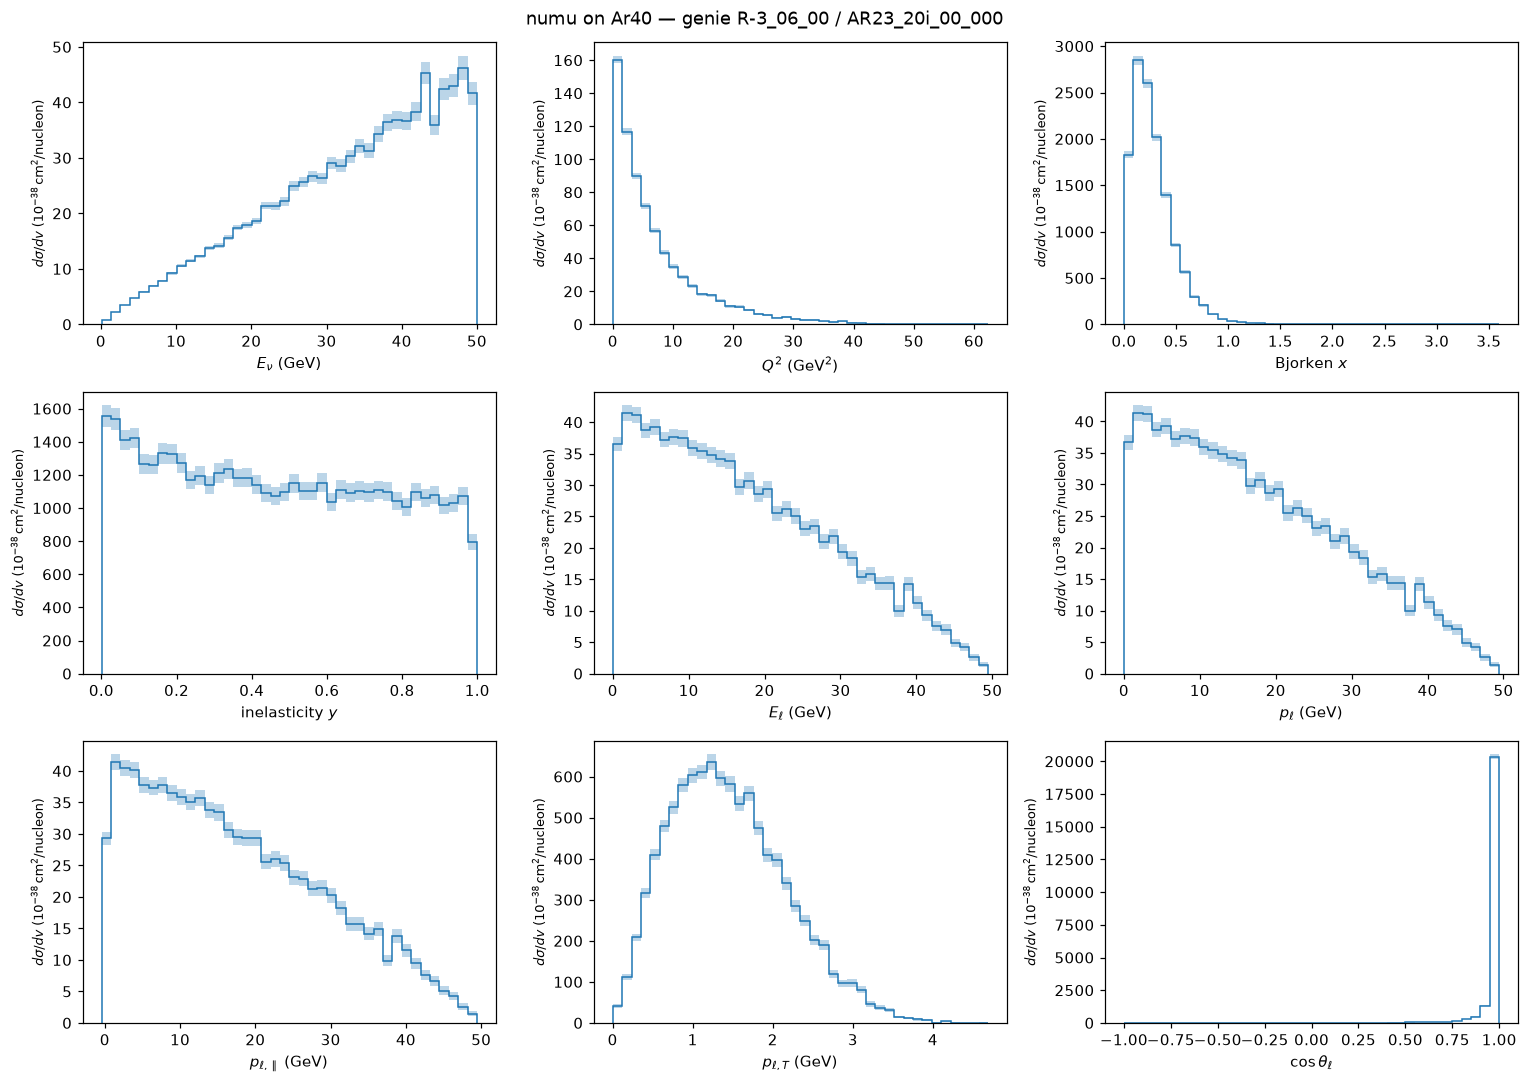

In [12]:
# (column, axis label). energy_gev leads: it is the one kinematic column with no
# placeholder, and it anchors the others.
PLOT_VARIABLES = (
    ("energy_gev", r"$E_\nu$ (GeV)"),
    ("q2_gev2", r"$Q^2$ (GeV$^2$)"),
    ("bjorken_x", r"Bjorken $x$"),
    ("inelasticity_y", r"inelasticity $y$"),
    ("lepton_energy_gev", r"$E_\ell$ (GeV)"),
    ("lepton_momentum_gev", r"$p_\ell$ (GeV)"),
    ("lepton_p_parallel_gev", r"$p_{\ell,\parallel}$ (GeV)"),
    ("lepton_p_transverse_gev", r"$p_{\ell,T}$ (GeV)"),
    ("lepton_costheta", r"$\cos\theta_\ell$"),
)


def xsec_density(values, weights, bin_edges):
    """Sum of weights per bin / bin width, with the weighted-count error."""
    sums, edges = np.histogram(values, bins=bin_edges, weights=weights)
    sum_sq, _ = np.histogram(values, bins=edges, weights=weights**2)
    widths = np.diff(edges)
    return sums / widths, np.sqrt(sum_sq) / widths, edges


def plot_variable(field, label, ax, bins=40):
    """One kinematic variable, weighted by xsec_weight, on `ax`."""
    mask = defined(field)
    values, weights = cols[field][mask], cols["xsec_weight"][mask]
    if values.size == 0:
        ax.text(0.5, 0.5, "no defined values", ha="center", va="center", transform=ax.transAxes)
        ax.set_xlabel(label)
        return

    edges = np.histogram_bin_edges(values, bins=bins)
    density, errors, edges = xsec_density(values, weights, edges)
    ax.stairs(density, edges, fill=False, color="C0")
    ax.stairs(
        density + errors, edges, baseline=density - errors, fill=True, color="C0", alpha=0.3
    )
    ax.set_xlabel(label)
    ax.set_ylabel(r"$d\sigma/dv$ ($10^{-38}\,\mathrm{cm}^2/\mathrm{nucleon}$)", fontsize="small")


fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, (field, label) in zip(np.ravel(axes), PLOT_VARIABLES):
    plot_variable(field, label, ax)
fig.suptitle(dataset_title(data))
fig.tight_layout()
plt.show()

## Plotting differential cross sections

The plots above do not correspond to anything physically useful. Differential cross sections are only meaningful in a slice of energy.

In order to compare to a paper like `PhysRevD.74.012008` (NuTeV), we need the double-differential cross section in x and y for each slice in energy, divided by energy.

In [27]:
e_slice = (30, 40) # min and max of the slice
e_midpoint = (e_slice[1] + e_slice[0]) / 2.0
e_volume = e_slice[1] - e_slice[0]
x_bin_edges = np.linspace(0, 1, 6)
y_bin_edges = np.linspace(0, 1, 11)

slice_mask = (cols["energy_gev"] >= e_slice[0]) & (cols["energy_gev"] < e_slice[1])
print(np.sum(slice_mask))

# now we create a 2D density histogram in x and y
hist2d, x_edges, y_edges = np.histogram2d(
    cols["bjorken_x"][slice_mask],
    cols["inelasticity_y"][slice_mask],
    bins=[x_bin_edges, y_bin_edges],
    weights=cols["xsec_weight"][slice_mask],
)
# the content in each bin has to be divided by the bin area to get the density.
# This includes the volume of the energy slice.
bin_areas = np.outer(np.diff(x_edges), np.diff(y_edges)) * e_volume
density2d = hist2d / bin_areas

4744


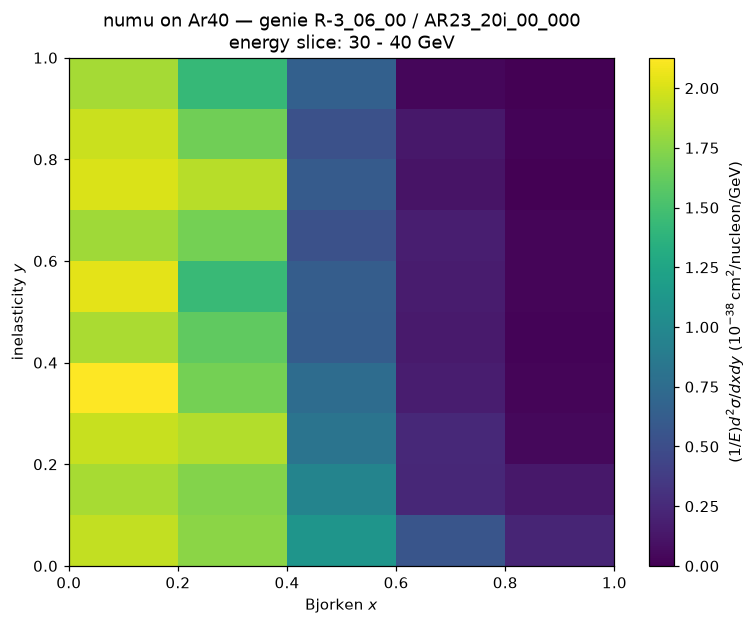

In [35]:
# Plot a 2D heatmap of the differential cross section we have just created. We divide by the midpoint energy of the slice to compare with the 1D differential cross section plots we made earlier.
plt.figure(figsize=(8, 6))
plt.imshow(
    density2d.T / e_midpoint,  # divide by the midpoint energy of the slice
    origin="lower",
    extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],
    aspect="auto",
    cmap="viridis",
)
plt.colorbar(label=r"$(1/E)d^2\sigma/dxdy$ ($10^{-38}\,\mathrm{cm}^2/\mathrm{nucleon}/\mathrm{GeV}$)")
plt.xlabel("Bjorken $x$")
plt.ylabel("inelasticity $y$")
plt.title(f"{dataset_title(data)}\nenergy slice: {e_slice[0]} - {e_slice[1]} GeV")
plt.show()

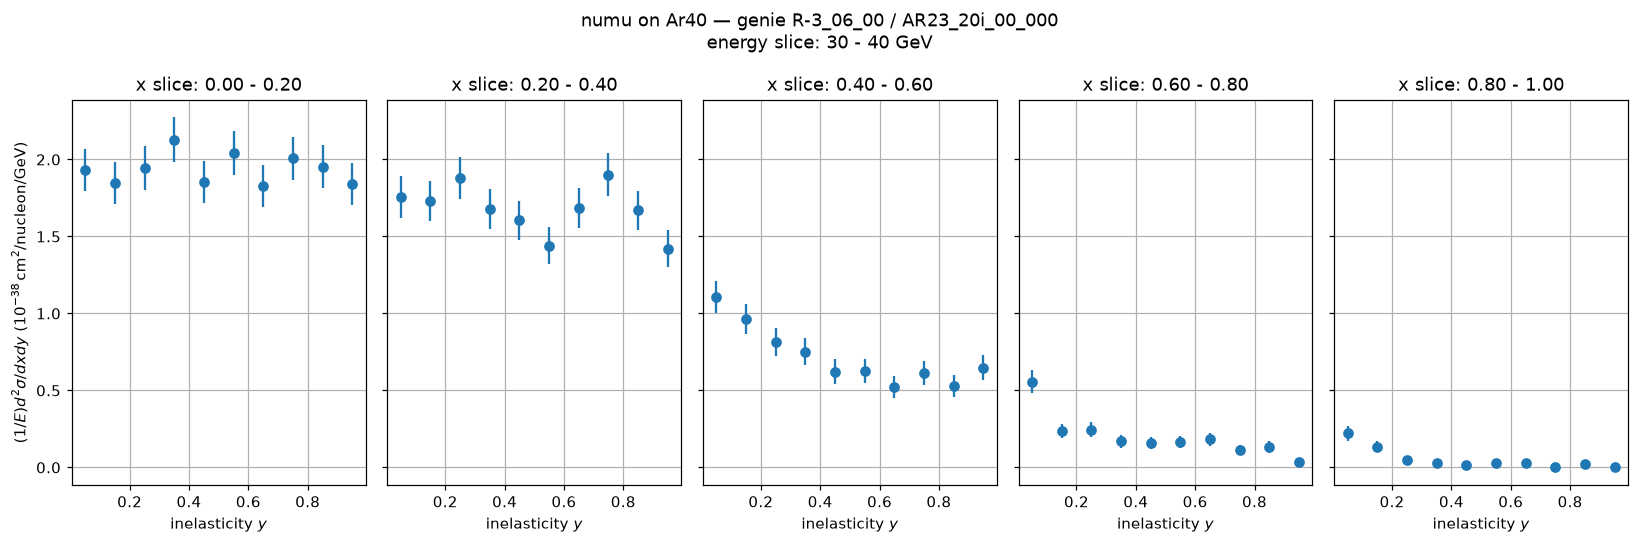

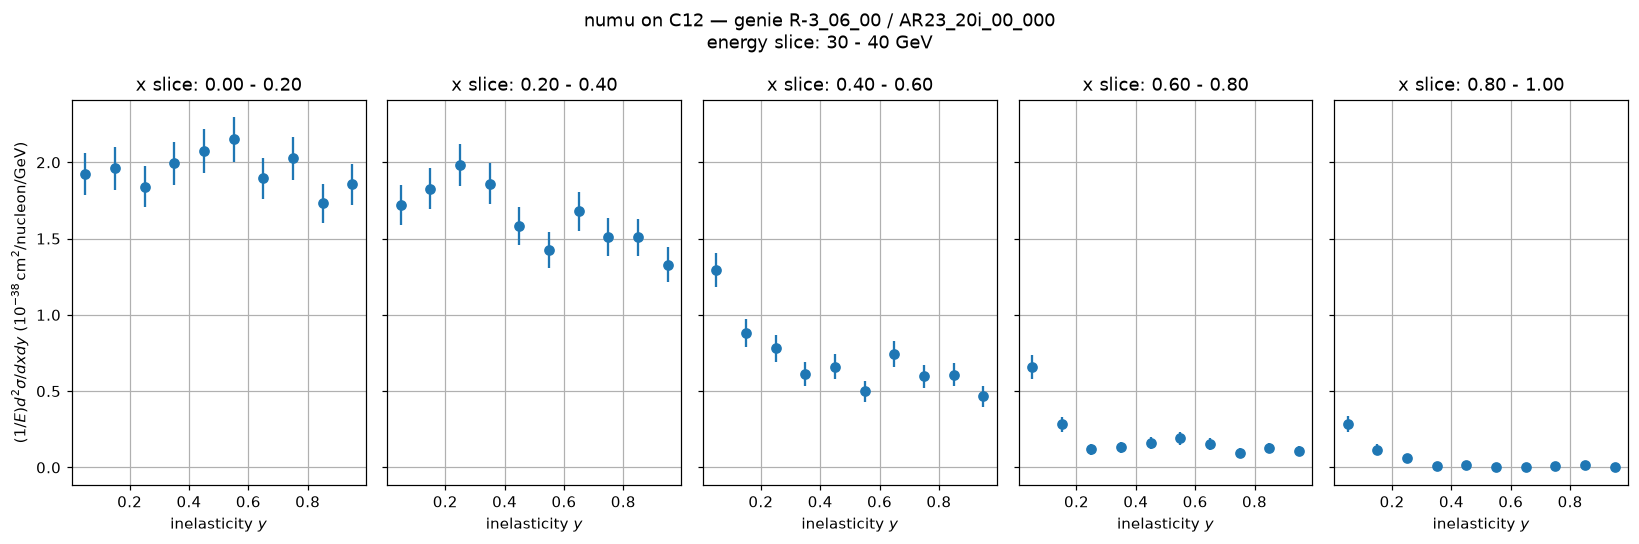

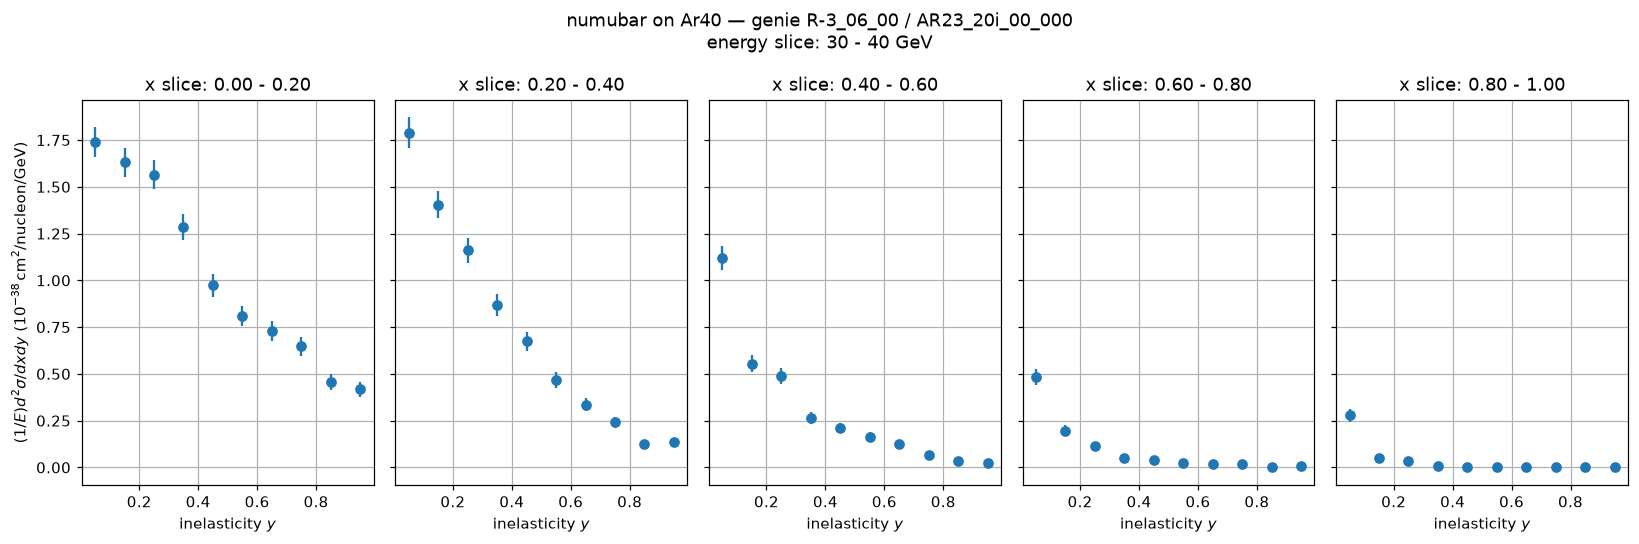

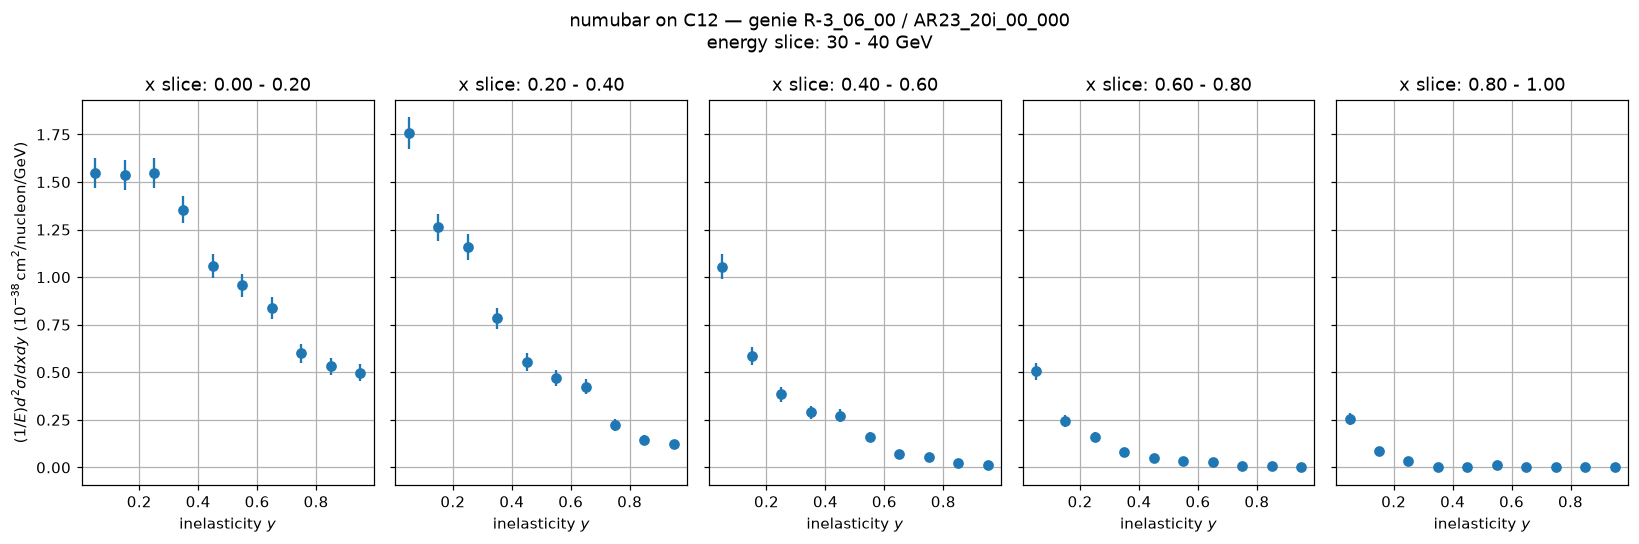

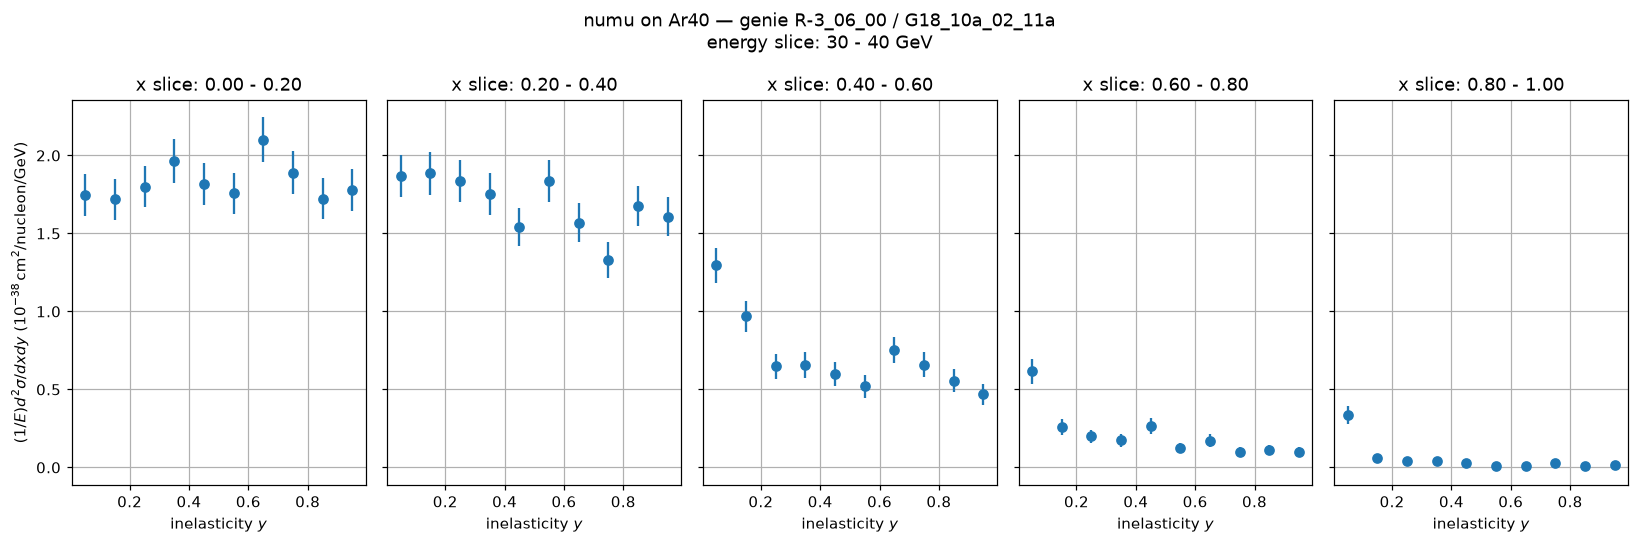

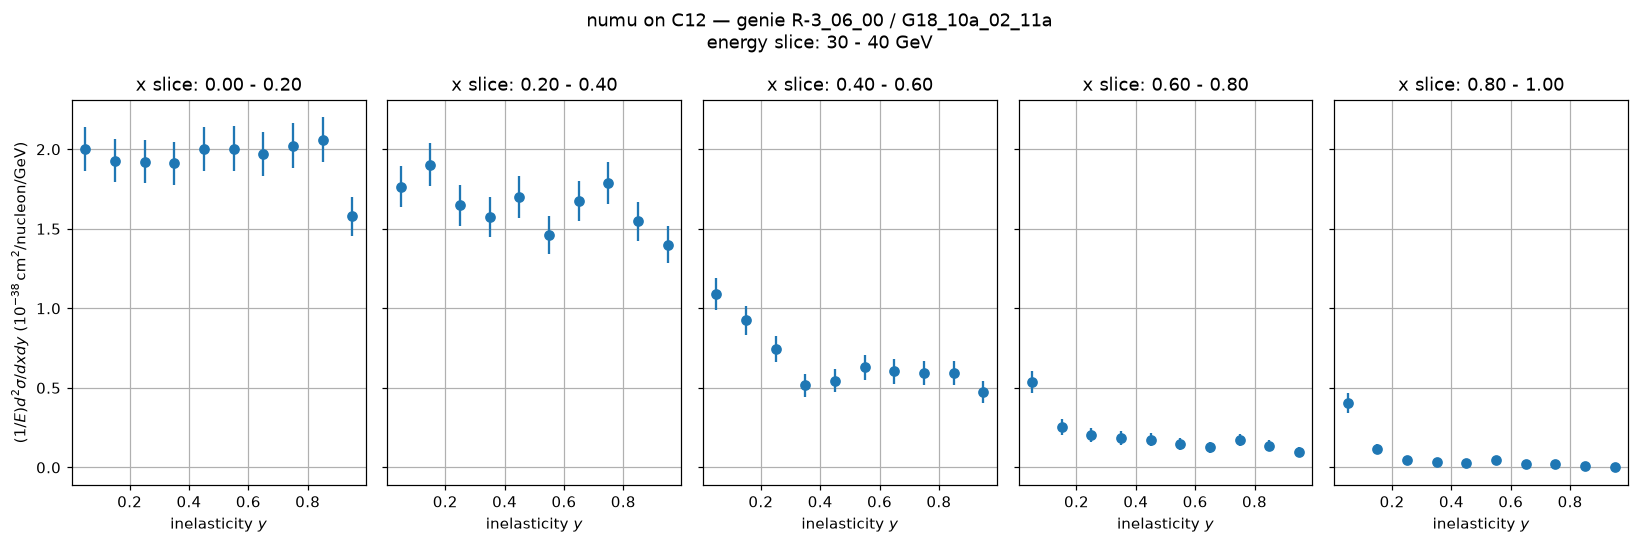

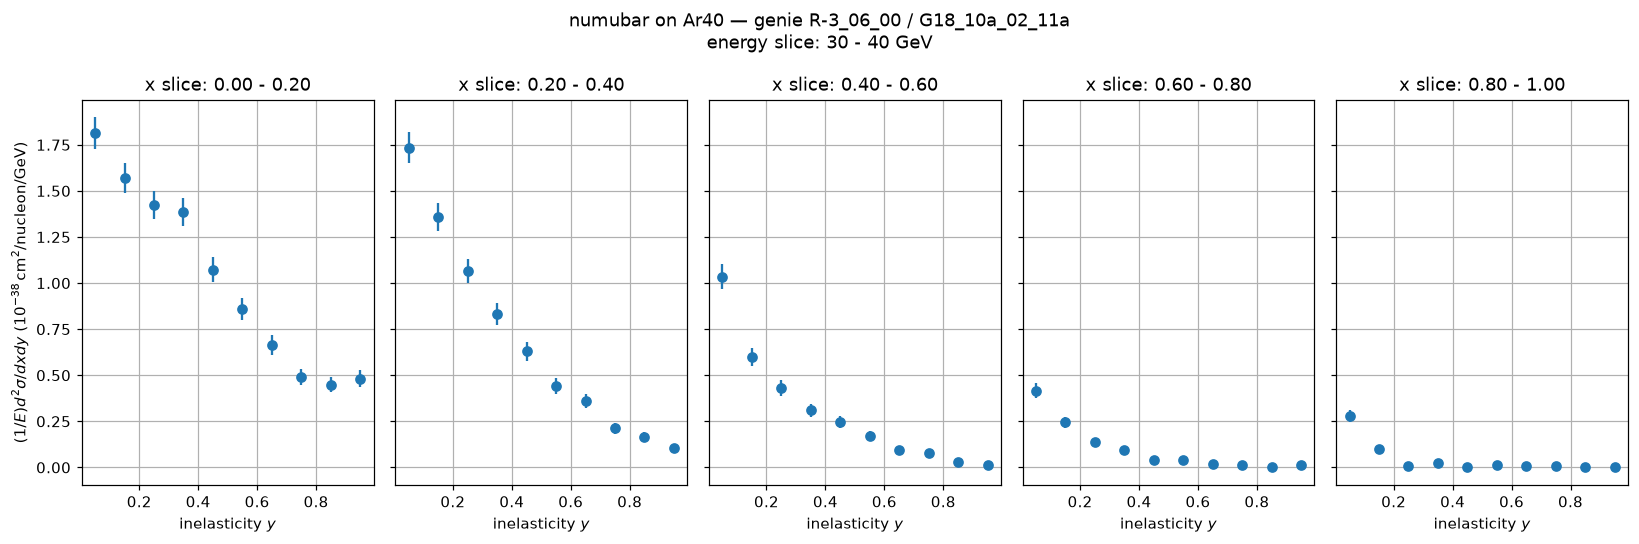

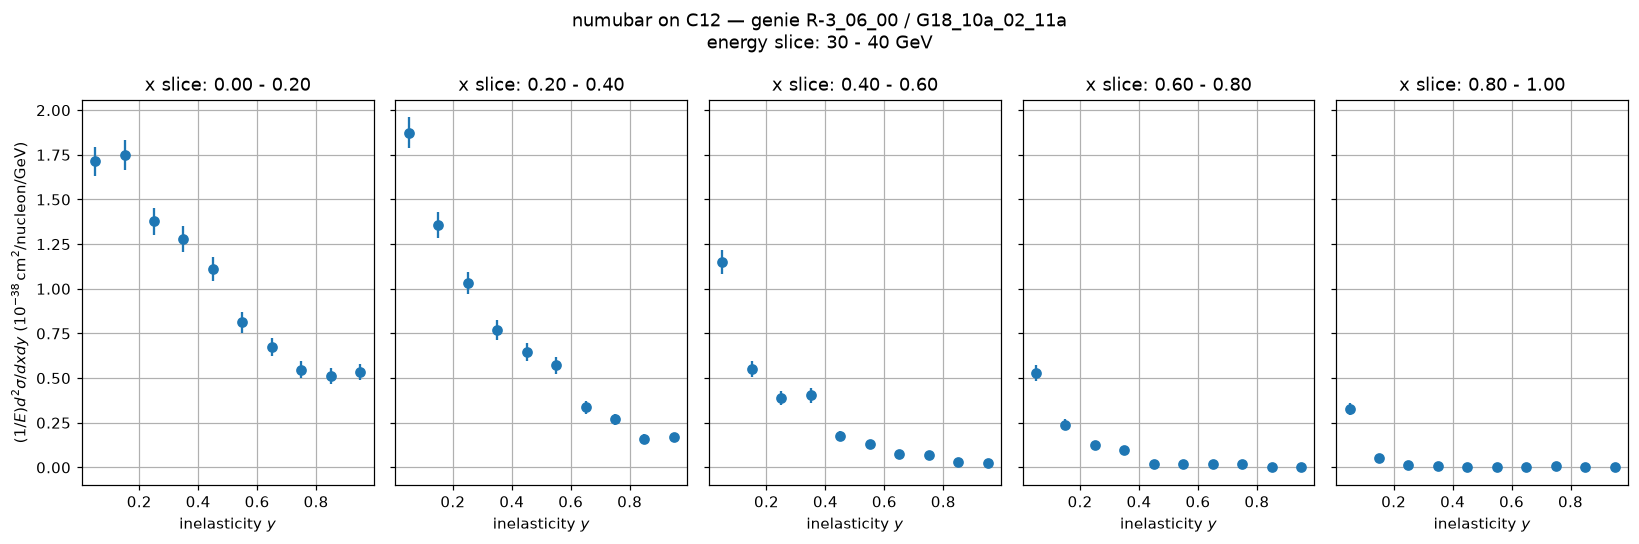

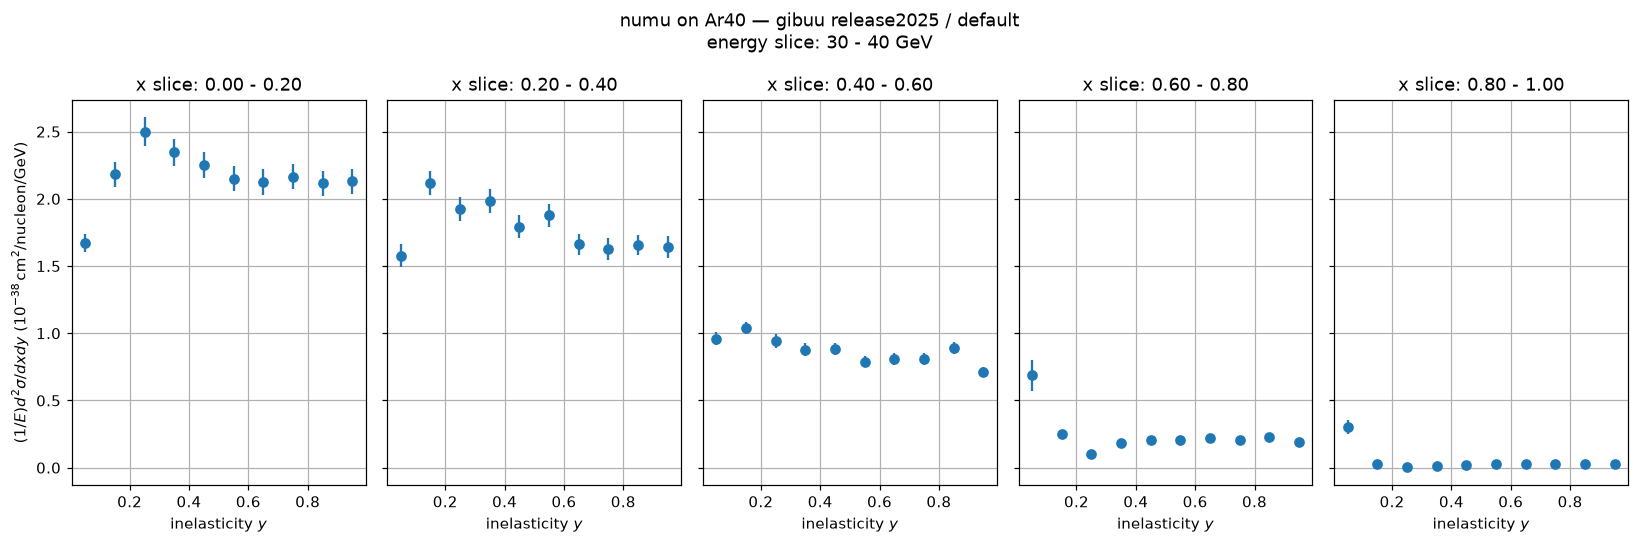

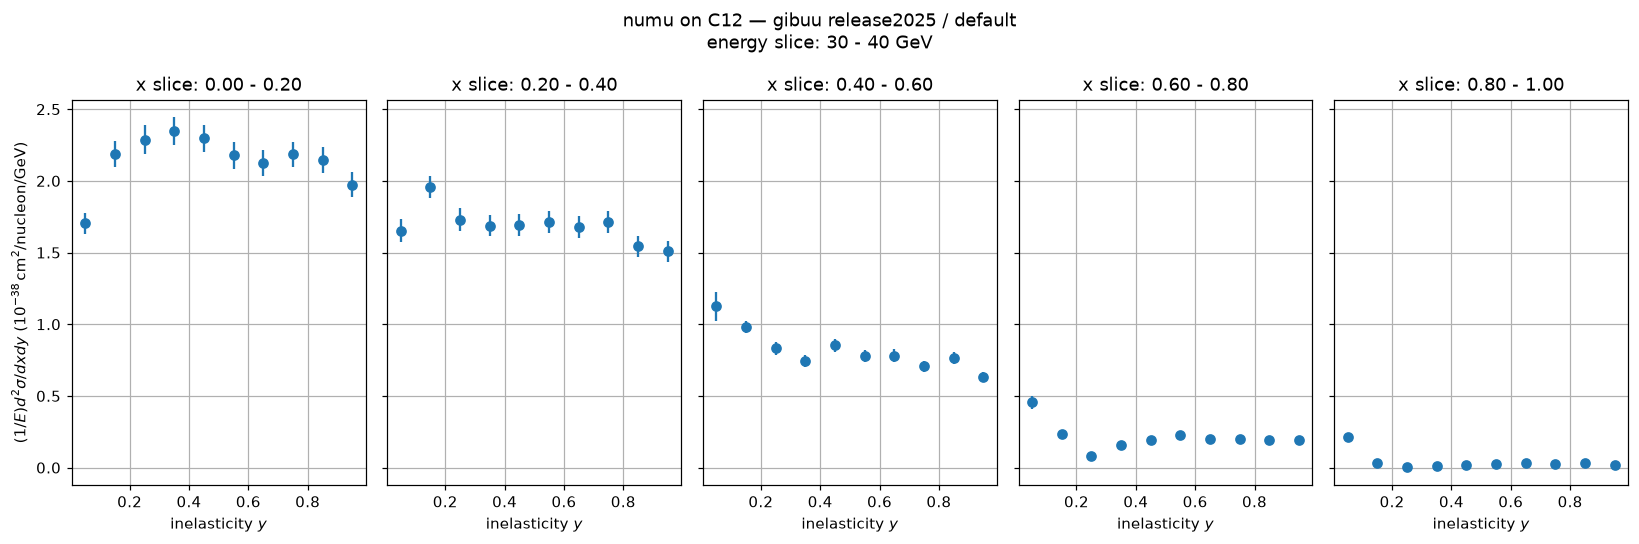

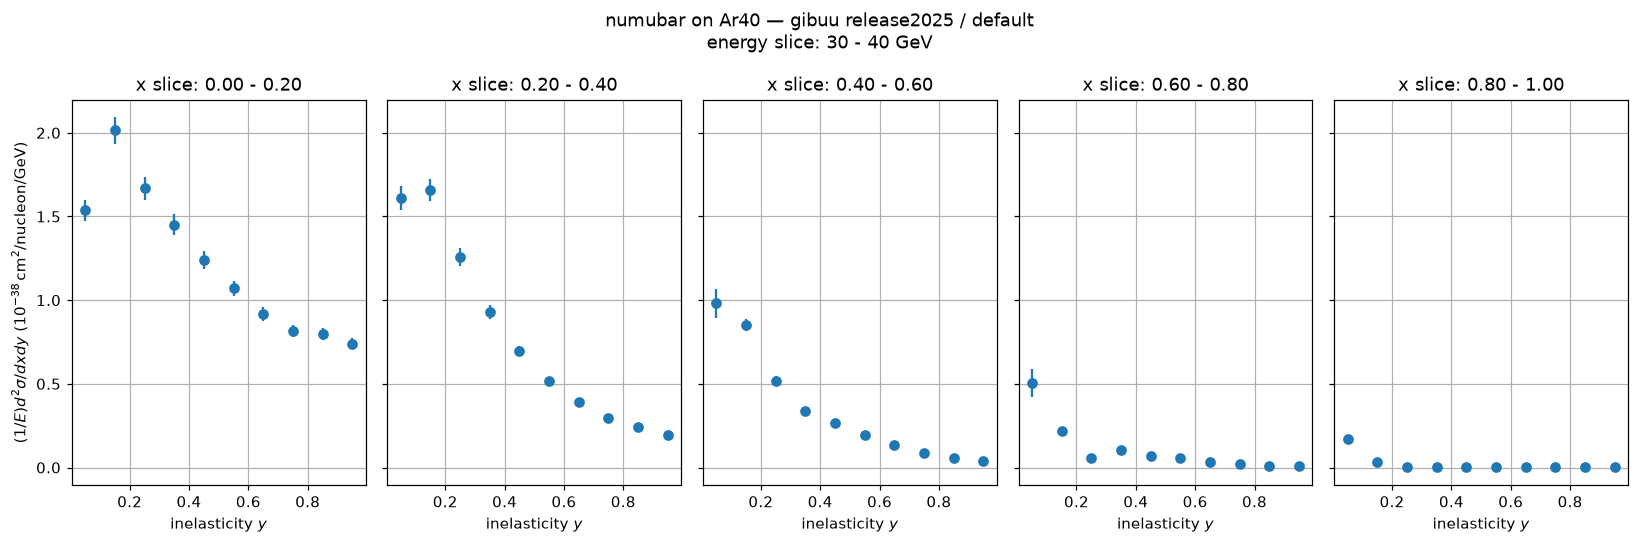

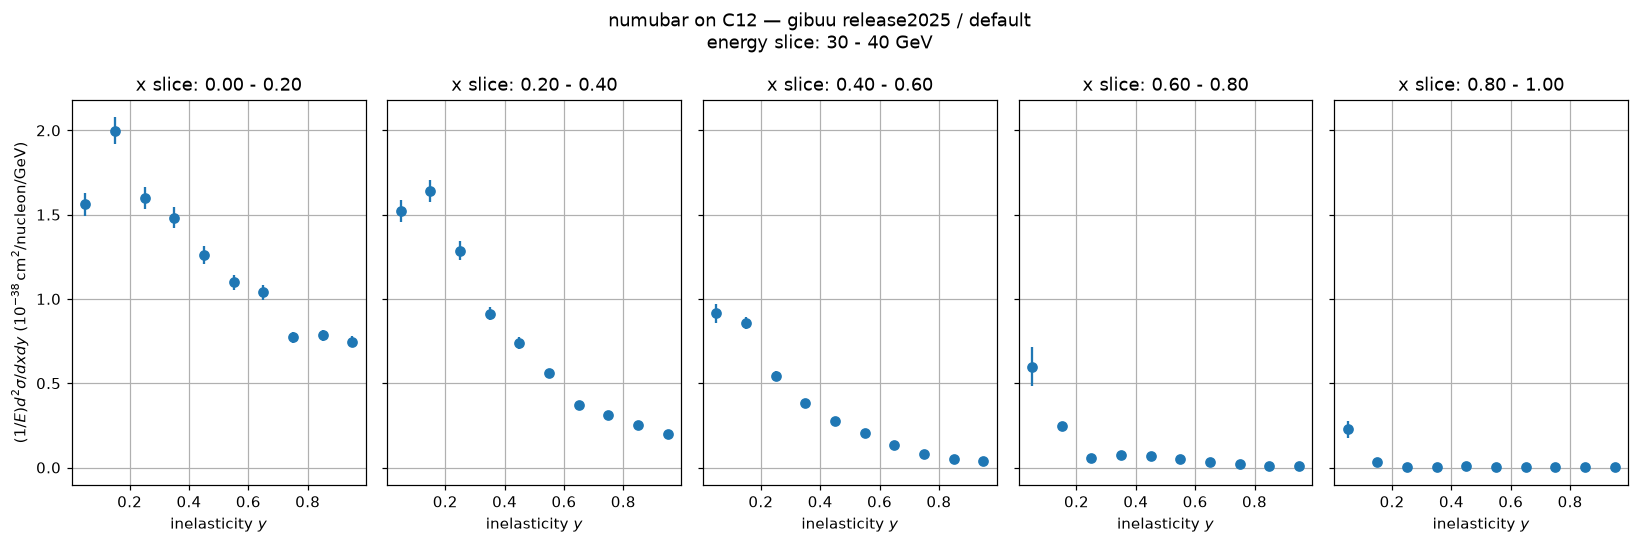

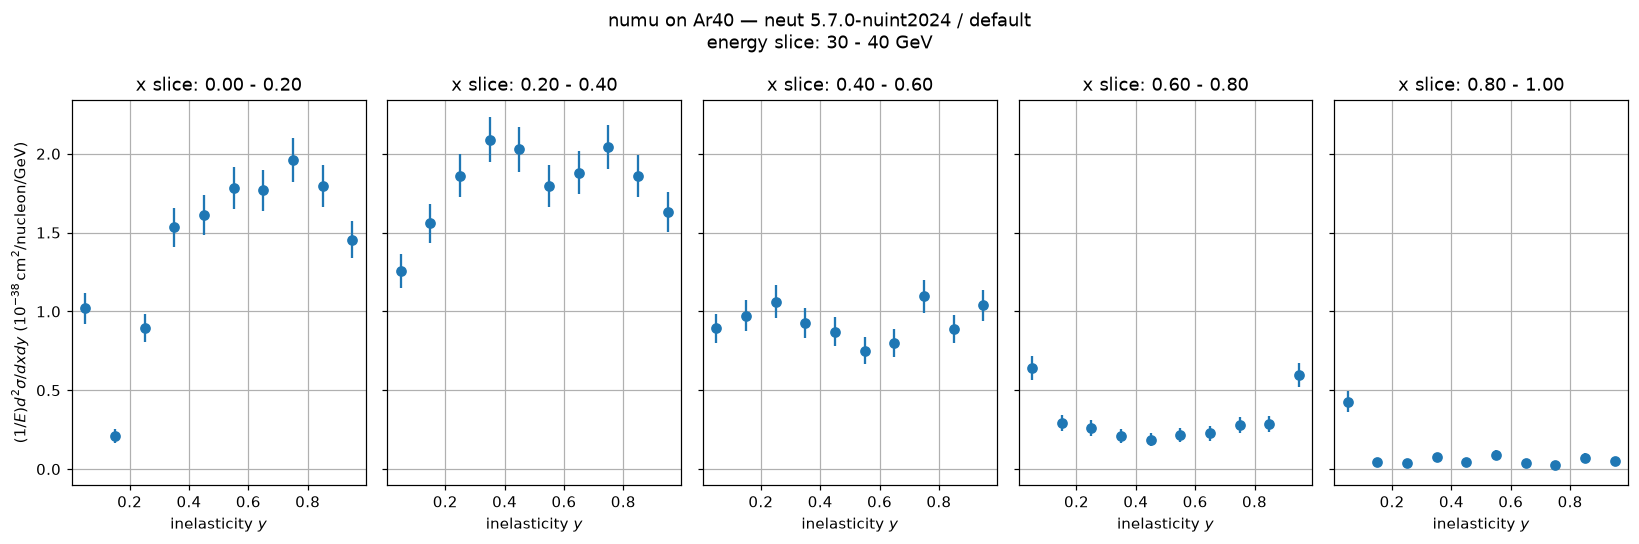

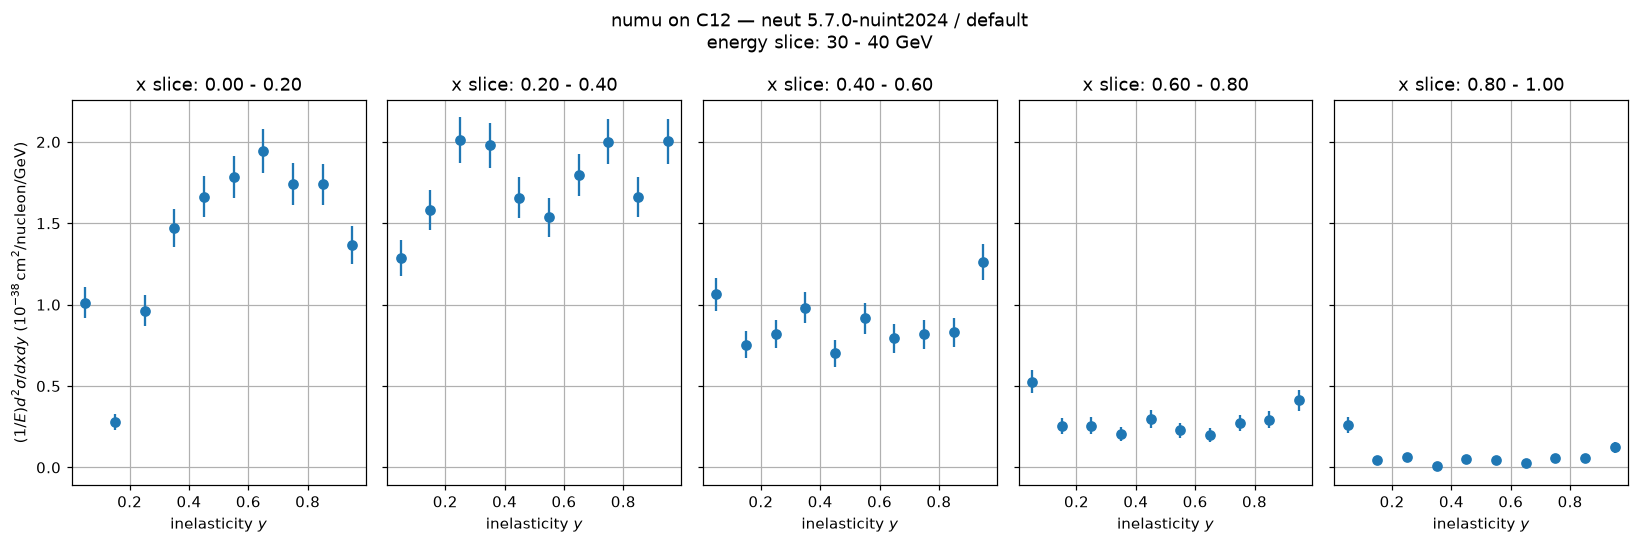

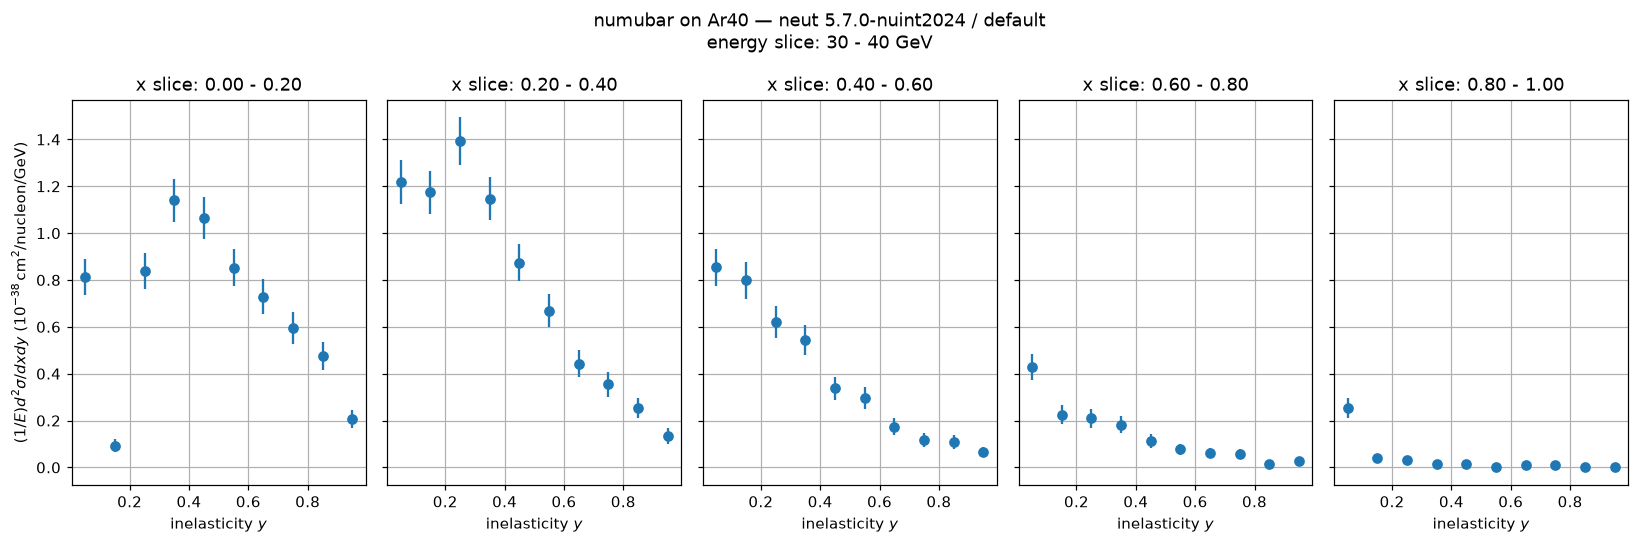

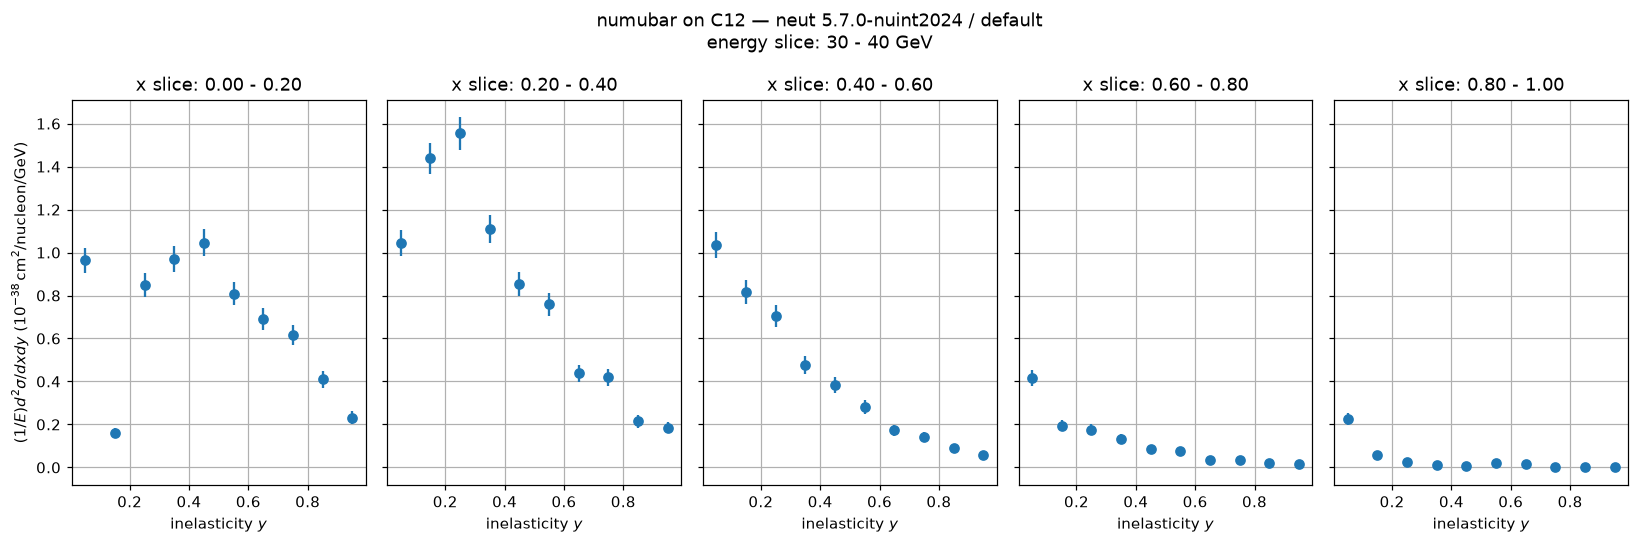

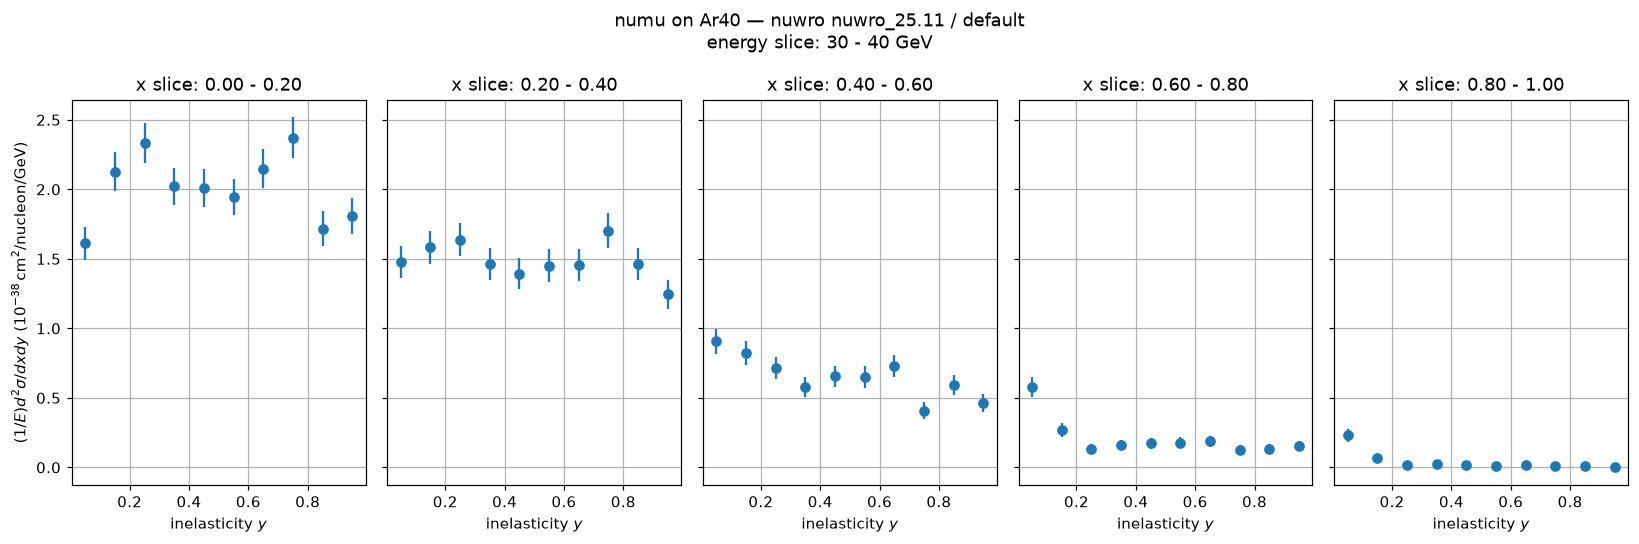

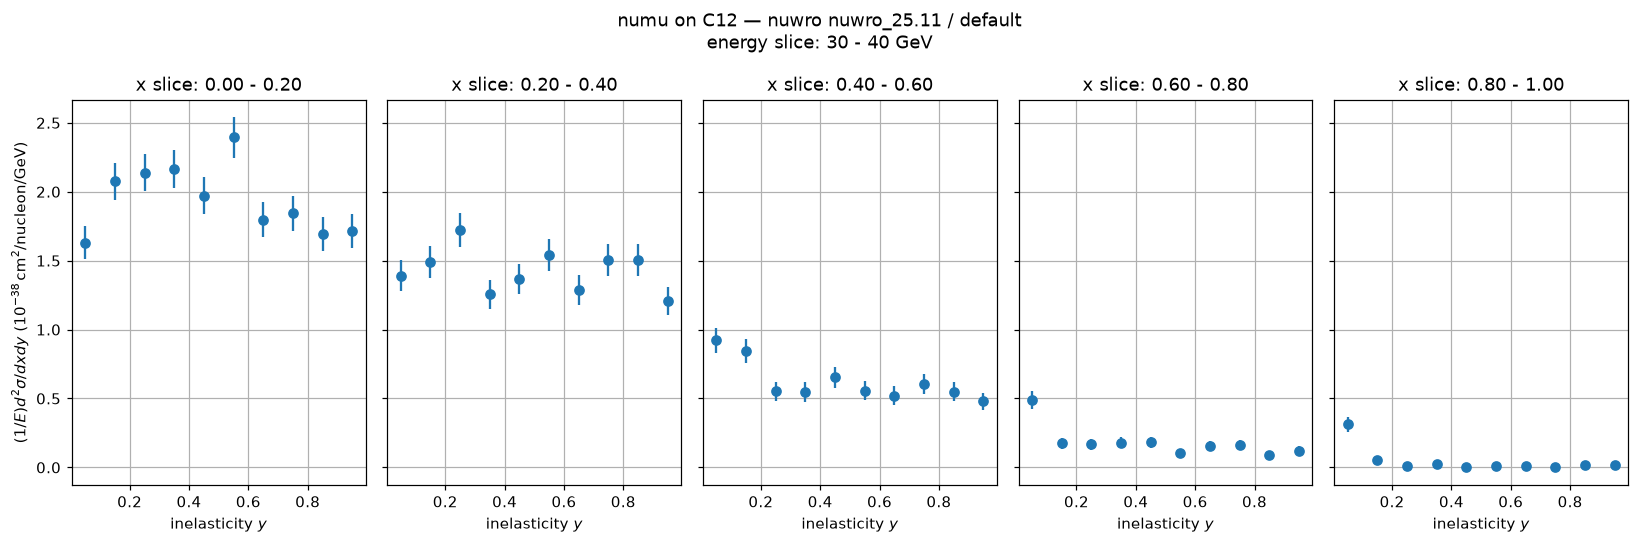

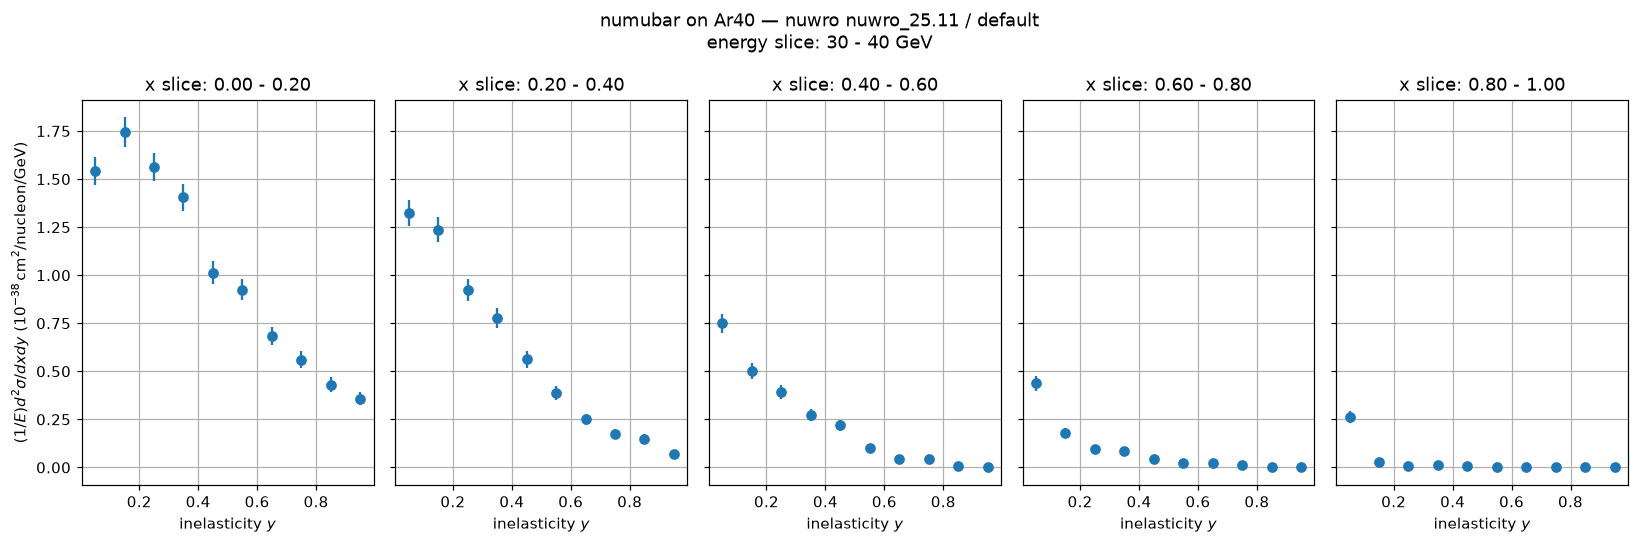

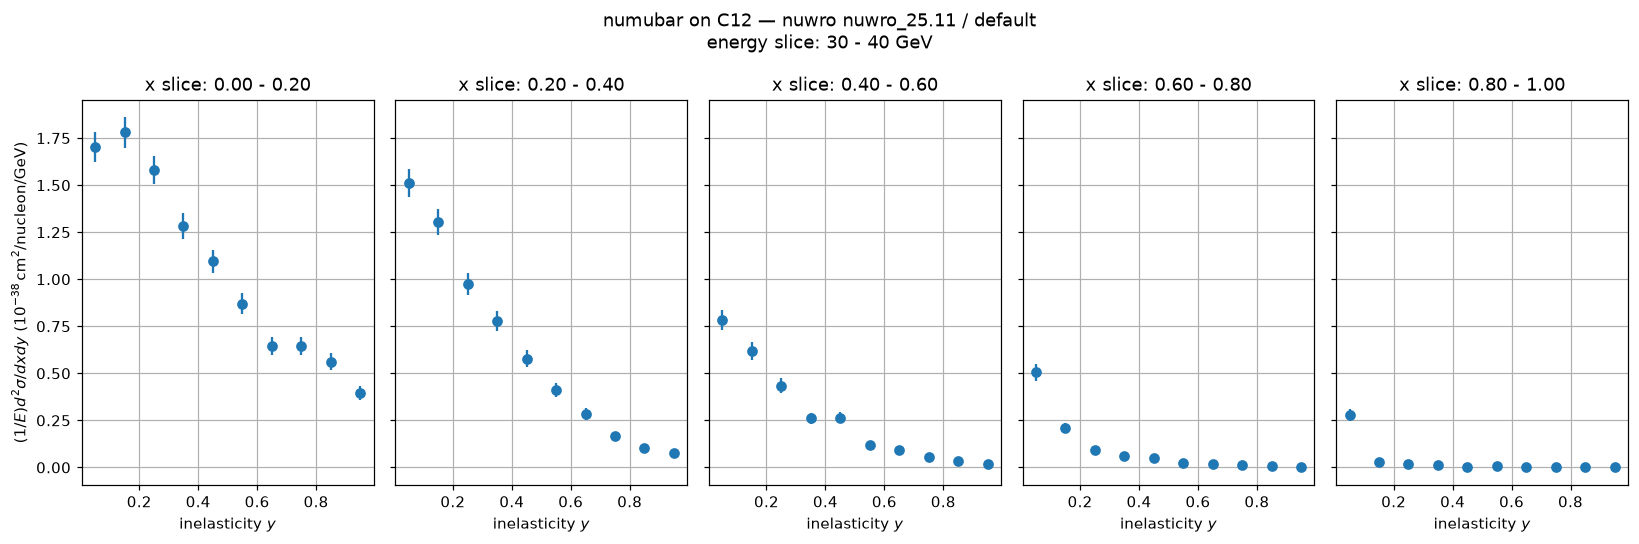

In [42]:
# Alternative plotting style: A multi-panel figure, one panel per slice in x, x-axis is y, plotting the differential cross section as a function of y for each slice in x.
# Error bars can then show the statistical uncertainty in each bin.
def plot_xsec_by_x_slice(path, e_slice=(30, 40), x_bin_edges=None, y_bin_edges=None, savepath=None):
    """Plot d^2 sigma / dx dy vs y for x slices in a single HDF5 output file."""
    if x_bin_edges is None:
        x_bin_edges = np.linspace(0, 1, 6)
    if y_bin_edges is None:
        y_bin_edges = np.linspace(0, 1, 11)

    metadata, cols_path = read_columns(path)
    data_path = read_plot_data(path)

    e_min, e_max = e_slice
    e_midpoint = (e_min + e_max) / 2.0
    e_volume = e_max - e_min

    valid = (
        (cols_path["energy_gev"] >= e_min)
        & (cols_path["energy_gev"] < e_max)
        & defined(cols_path, "bjorken_x")
        & defined(cols_path, "inelasticity_y")
        & np.isfinite(cols_path["xsec_weight"])
    )

    fig, axes = plt.subplots(1, len(x_bin_edges) - 1, figsize=(15, 5), sharey=True)
    for i in range(len(x_bin_edges) - 1):
        x_slice_mask = (
            (cols_path["bjorken_x"] >= x_bin_edges[i])
            & (cols_path["bjorken_x"] < x_bin_edges[i + 1])
            & valid
        )
        x_slice_width = x_bin_edges[i + 1] - x_bin_edges[i]

        axes[i].set_title(f"x slice: {x_bin_edges[i]:.2f} - {x_bin_edges[i + 1]:.2f}")
        axes[i].set_xlabel("inelasticity $y$")

        if not np.any(x_slice_mask):
            axes[i].text(0.5, 0.5, "no events", ha="center", va="center", transform=axes[i].transAxes)
            continue

        hist_y, y_edges = np.histogram(
            cols_path["inelasticity_y"][x_slice_mask],
            bins=y_bin_edges,
            weights=cols_path["xsec_weight"][x_slice_mask],
        )
        sum_sq_y, _ = np.histogram(
            cols_path["inelasticity_y"][x_slice_mask],
            bins=y_edges,
            weights=cols_path["xsec_weight"][x_slice_mask] ** 2,
        )

        bin_widths_y = np.diff(y_edges)
        density_y = hist_y / bin_widths_y / e_volume / x_slice_width
        errors_y = np.sqrt(sum_sq_y) / bin_widths_y / e_volume / x_slice_width

        density_y /= e_midpoint
        errors_y /= e_midpoint

        axes[i].errorbar(
            (y_edges[:-1] + y_edges[1:]) / 2,
            density_y,
            yerr=errors_y,
            fmt="o",
        )
        axes[i].grid()

    axes[0].set_ylabel(r"$(1/E)d^2\sigma/dxdy$ ($10^{-38}\,\mathrm{cm}^2/\mathrm{nucleon}/\mathrm{GeV}$)")
    fig.suptitle(f"{dataset_title(data_path)}\nenergy slice: {e_min} - {e_max} GeV")
    fig.tight_layout()
    if savepath is not None:
        fig.savefig(savepath)
    plt.show()

out_dir = "explore_output"
for path in available:
    plot_xsec_by_x_slice(path, savepath=f"{out_dir}/{os.path.basename(path)}.png")